In [1]:
import numpy as np
from scipy.integrate import simpson
from scipy.stats import skewnorm
import bagpipes as pipes
from matplotlib import pyplot as plt

from joblib import Parallel, delayed
import warnings
from astropy.cosmology import FlatLambdaCDM

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


In [2]:
import pandas as pd

# Carregamento dos dados do modelo sintetico e do splus
splus_all_data = pd.read_csv("dr3_alldata.csv")
filter_splus = (splus_all_data['u_auto'] < 21.3) & (splus_all_data['g_auto'] < 21.3) & (splus_all_data['r_auto'] < 21.3) & (splus_all_data['i_auto'] < 21.3) & (splus_all_data['z_auto'] < 21.3) \
               & (splus_all_data['J0378_auto'] < 21.3) & (splus_all_data['J0395_auto'] < 21.3) & (splus_all_data['J0410_auto'] < 21.3) & (splus_all_data['J0430_auto'] < 21.3) \
               & (splus_all_data['J0515_auto'] < 21.3) & (splus_all_data['J0660_auto'] < 21.3) & (splus_all_data['J0861_auto'] < 21.3) & (splus_all_data['e_r_auto'] < 0.01)

splus_data = splus_all_data[filter_splus].reset_index(drop=True)

In [ ]:
import itertools

# Carrega a lista de filtros
filt_splus_list = np.loadtxt("splus-filters/splus_filters.txt", dtype="str")
n_filters_splus = len(filt_splus_list)

cosmo = FlatLambdaCDM(H0=70.0, Om0=0.3)

central_wavs = np.zeros(n_filters_splus)
for j in range(n_filters_splus):
    filt = np.loadtxt(filt_splus_list[j])
    num = simpson(filt[:, 1] * filt[:, 0], x=filt[:, 0])
    den = simpson(filt[:, 1] / filt[:, 0], x=filt[:, 0])
    central_wavs[j] = np.sqrt(num / den)

# ====================================================================
# GRID DEFINITION FOR SYNTHETIC DOMAIN
# ====================================================================
grid_age = np.array([0.1, 0.5, 1.0, 3.0, 5.0, 7.0])
grid_tau = np.array([0.1, 0.5, 1.0, 3.0, 10.0])
raw_Z = np.array([0.0059, 0.029, 0.24, 0.47, 1.00, 1.76, 3.53])
grid_Z = np.unique(np.clip(raw_Z, 0.00005, 1.0))
grid_Av = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])

synthetic_domain_grid = list(itertools.product(grid_age, grid_tau, grid_Z, grid_Av))
total_grid_samples = len(synthetic_domain_grid)

ROW_LEN = 5 + n_filters_splus

def ab_mags(phot):
    """AB magnitudes: photometry in erg/s/cm^2/A, central_wavs in um."""
    mags = np.full(n_filters_splus, np.nan)
    valid = np.isfinite(phot) & (phot > 0.0)
    mags[valid] = -2.5 * np.log10(phot[valid]) - 5 * np.log10(central_wavs[valid]) - 2.406
    return mags

def worker_bagpipes(params):
    age, tau, Z, Av = params

    max_allowed_age = cosmo.age(0.01).value - 0.1
    if age > max_allowed_age:
        return np.full(ROW_LEN, np.nan)

    sfh_exponential = {
        "age": age,
        "tau": tau,
        "massformed": 10.0,   # log10(M_formed/M_sun) -> 1e10 M_sun total formed
        "metallicity": Z      # Z/Z_sun, 1.0 = solar
    }

    dust = {"type": "CF00", "Av": Av, "eta": 2.0, "n": 0.7}
    nebular = {"logU": -2.5}

    model_components = {
        "redshift": 0.01,
        "t_bc": 0.01,
        "exponential": sfh_exponential,
        "dust": dust,
        "nebular": nebular,
    }

    model = pipes.model_galaxy(model_components, filt_list=filt_splus_list)
    
    if np.any(model.photometry <= 0.0):
        return np.full(n_filters_splus, np.nan)
    
    test_splus = -2.5 * np.log10(model.photometry) - 5 * np.log10(central_wavs) - 2.406
    return test_splus

if __name__ == '__main__':
    threads = 10

    print(f"Mapping Synthetic Domain with {total_grid_samples} total grid points...")

    mock_test = np.array(
            Parallel(n_jobs=threads, verbose=10)(
                delayed(worker_bagpipes)(params) for params in synthetic_domain_grid
            )
        )
    
    np.savetxt("output.csv", mock_test, delimiter=",", header=",".join(filt_splus_list), comments="")

Mapping Synthetic Domain with 900 total grid points...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.
Bagpipes: Latex turned off in rcParams, plots may look strange.Bagpipes: Latex turned off in rcParams, plots may look strange.

Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots ma

[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    2.9s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:    3.3s
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:    3.7s
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    4.1s
[Parallel(n_jobs=10)]: Done  41 tasks      | elapsed:    4.5s
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:    4.9s
[Parallel(n_jobs=10)]: Done  65 tasks      | elapsed:    5.3s
[Parallel(n_jobs=10)]: Done  78 tasks      | elapsed:    5.8s
[Parallel(n_jobs=10)]: Done  93 tasks      | elapsed:    6.4s
[Parallel(n_jobs=10)]: Done 108 tasks      | elapsed:    6.9s
[Parallel(n_jobs=10)]: Done 125 tasks      | elapsed:    7.3s
[Parallel(n_jobs=10)]: Done 142 tasks      | elapsed:    8.0s
[Parallel(n_jobs=10)]: Done 161 tasks      | elapsed:    8.7s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    9.4s
[Parallel(n_jobs=10)]: Done 201 tasks      | elapsed:   10.1s
[Parallel(n_jobs=10)]: Done 222 tasks      | elapsed:   10.9s
[Paralle

['uJAVA', 'F0378', 'F0395', 'F0410', 'F0430', 'gSDSS', 'F0515', 'rSDSS', 'F0660', 'iSDSS', 'F0861', 'zSDSS']


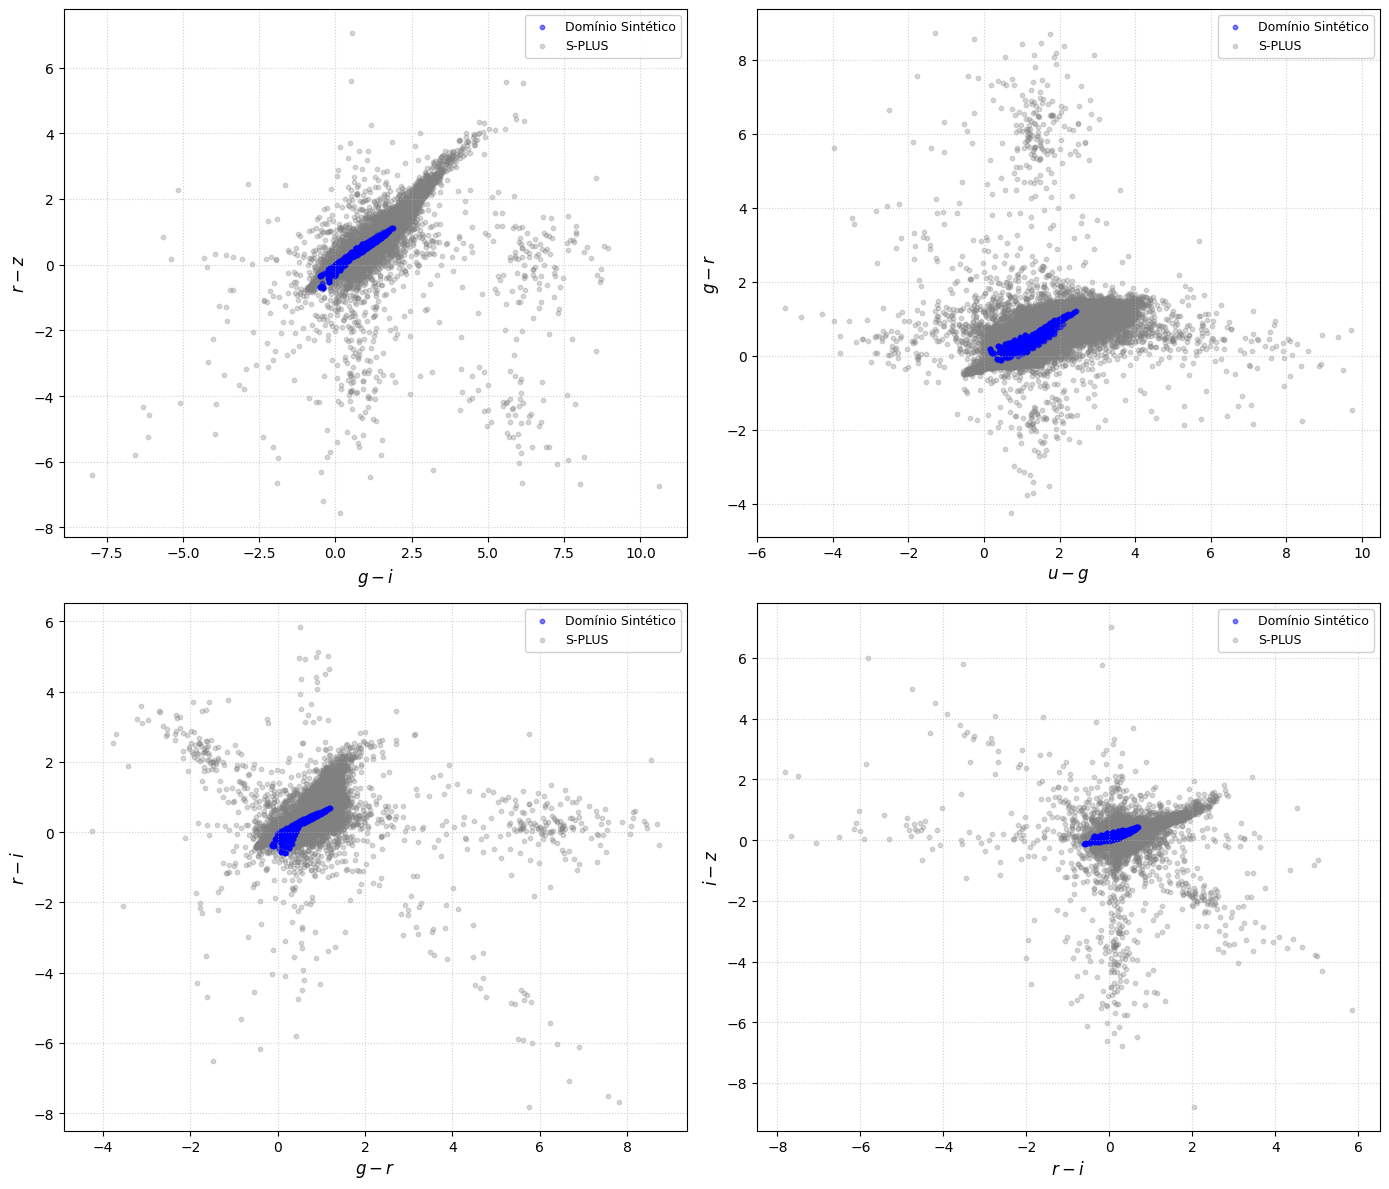

In [15]:
from scipy.spatial import ConvexHull
from matplotlib.lines import Line2D

plt.rcParams["text.usetex"] = False

model_grid = np.loadtxt("output.csv", delimiter=",", skiprows=1)
filt_splus_list = [filter.split("/")[1].split(".")[0] for filter in np.loadtxt("splus-filters/splus_filters.txt", dtype="str")]

print(filt_splus_list)

plot_configs = [
    {'x': ('gSDSS', 'iSDSS'), 'y': ('rSDSS', 'zSDSS'), 'xlab': '$g - i$', 'ylab': '$r - z$'},
    {'x': ('uJAVA', 'gSDSS'),  'y': ('gSDSS', 'rSDSS'), 'xlab': '$u - g$', 'ylab': '$g - r$'},
    {'x': ('gSDSS', 'rSDSS'), 'y': ('rSDSS', 'iSDSS'), 'xlab': '$g - r$', 'ylab': '$r - i$'},
    {'x': ('rSDSS', 'iSDSS'), 'y': ('iSDSS', 'zSDSS'), 'xlab': '$r - i$', 'ylab': '$i - z$'}
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

cmap = plt.get_cmap('jet')

# Loop sobre cada subplot e sua configuração de cor
for ax_idx, (ax, config) in enumerate(zip(axes, plot_configs)):
    
    b1_x, b2_x = config['x']
    b1_y, b2_y = config['y']
    
    all_x, all_y = [], []

    ax.scatter(model_grid[:, filt_splus_list.index(b1_x)] - model_grid[:, filt_splus_list.index(b2_x)],
               model_grid[:, filt_splus_list.index(b1_y)] - model_grid[:, filt_splus_list.index(b2_y)],
               c='blue', s=10, alpha=0.5, label='Domínio Sintético', zorder=1)

    splus_data_x = splus_data[b1_x[0] + '_auto'] - splus_data[b2_x[0] + '_auto']
    splus_data_y = splus_data[b1_y[0] + '_auto'] - splus_data[b2_y[0] + '_auto']

    ax.scatter(splus_data_x, splus_data_y, color='gray', alpha=0.3, s=10, zorder=0, label="S-PLUS") # Dados S-PLUS
    
    # Estilização de cada subplot
    ax.set_xlabel(config['xlab'], fontsize=12)
    ax.set_ylabel(config['ylab'], fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)

    ax.legend(loc='best', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()